In [1]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
df=pd.read_csv('MS_Dhoni_ODI_record.csv')

In [3]:
print(df.head())
print(df.tail())

  score runs_scored balls_faced strike_rate fours sixes    opposition  \
0     0           0           1           0     0     0  v Bangladesh   
1    12          12          11      109.09     2     0  v Bangladesh   
2    7*           7           2         350     0     1  v Bangladesh   
3     3           3           7       42.85     0     0    v Pakistan   
4   148         148         123      120.32    15     4    v Pakistan   

          ground        date  odi_number  
0     Chattogram  23/12/2004  ODI # 2199  
1          Dhaka  26/12/2004  ODI # 2201  
2          Dhaka  27/12/2004  ODI # 2202  
3          Kochi  02/04/2005  ODI # 2235  
4  Visakhapatnam  05/04/2005  ODI # 2236  
    score runs_scored balls_faced strike_rate fours sixes     opposition  \
345   56*          56          61        91.8     3     2  v West Indies   
346   42*          42          31      135.48     4     1      v England   
347    35          35          33      106.06     4     0   v Bangladesh   

In [4]:
#data cleaning
df['opposition']=df['opposition'].str.replace('v ','',regex=False)
print(df['opposition'])

0       Bangladesh
1       Bangladesh
2       Bangladesh
3         Pakistan
4         Pakistan
          ...     
345    West Indies
346        England
347     Bangladesh
348      Sri Lanka
349    New Zealand
Name: opposition, Length: 350, dtype: object


In [5]:
df.columns

Index(['score', 'runs_scored', 'balls_faced', 'strike_rate', 'fours', 'sixes',
       'opposition', 'ground', 'date', 'odi_number'],
      dtype='object')

In [6]:
df.drop(columns=['odi_number'],inplace=True)

In [7]:
df.columns

Index(['score', 'runs_scored', 'balls_faced', 'strike_rate', 'fours', 'sixes',
       'opposition', 'ground', 'date'],
      dtype='object')

In [10]:
#creating not_out columns
df['score']=df['score'].apply(str)
df['not_out']= np.where(df['score'].str.endswith('*'),1,0)

In [12]:
#filtering out innings wher Dhoni did not bat/Team did not bat
df_new=df.loc[((df['score']!='DNB') & (df['score']!='TDNB')),'runs_scored':]

In [15]:
# FIX THE DATATYPES
df_new['run_scored']= df_new['runs_scored'].astype(int)
df_new['balls_faced']=df_new['balls_faced'].astype(int)
df_new['strike_rate']=df_new['strike_rate'].astype(float)
df_new['fours']=df_new['fours'].astype(int)
df_new['sixes']=df_new['sixes'].astype(int)


In [18]:
#career stats
df['date']=pd.to_datetime(df['date'],dayfirst=True)
first_match_date=df['date'].dt.date.min().strftime('%B,%d,%Y')
#dt gives the access to pandas date time properties
#date converts each datetime value to python date object

In [20]:
last_match_date=df['date'].dt.date.max().strftime('%B,%d,%Y')
print('First match',first_match_date)
print('Last match',last_match_date)


First match December,23,2004
Last match July,09,2019


In [23]:
number_of_matches=df.shape[0]
print('Number of matches',number_of_matches)
number_of_innings=df_new.shape[0]
print('Number of innings',number_of_innings)

Number of matches 350
Number of innings 297


In [24]:
not_outs= df_new['not_out'].sum()
print('Not outs',not_outs)


Not outs 84


In [25]:
runs_scored= df_new['runs_scored'].sum()
print('Runs scored in the career',runs_scored)
balls_faced=df_new['balls_faced'].sum()
print('Balls faced in the career', balls_faced)

Runs scored in the career 0127314828471124215202872563767113818345080171412687227720381310963591821546142182375128145526446264048670290913623313901419211313243550583350426563449452437881731375036153624641092676674963976711391529950612335945384236894195463585633412471266247210737101321426689385641382231038670253852531341912227259133669785087351575294445856144621435113158113543632721019152702745191392562135123651940565079475229851619341718184585665547693192471527181123034213980114161342563491378544567491795313251825657410421337420338362072351558748159026342712856423550
Balls faced in the career 12303


opposition
Sri Lanka       67
Australia       55
England         48
West Indies     39
South Africa    37
Pakistan        36
New Zealand     28
Bangladesh      21
Zimbabwe         6
Africa XI        3
Hong Kong        2
Ireland          2
Afghanistan      2
Bermuda          1
Scotland         1
Netherlands      1
U.A.E.           1
Name: count, dtype: int64


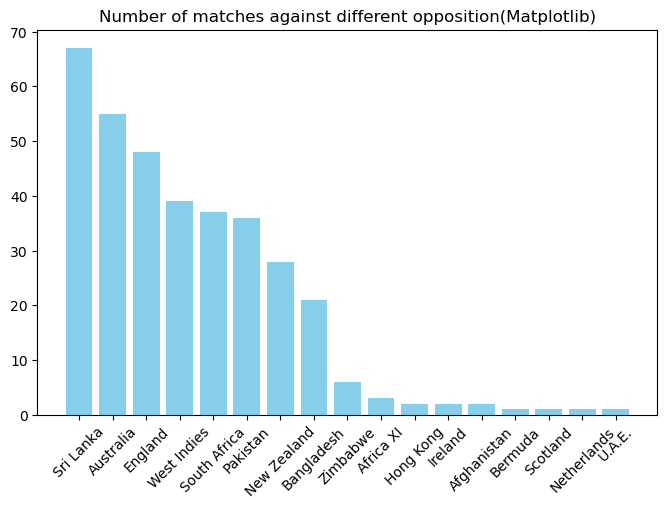

In [27]:
# matches against different opposition
opposition_counts=df['opposition'].value_counts()
print(opposition_counts)
#Matplotlib bar plat
plt.figure(figsize=(8,5))
plt.bar(opposition_counts.index,opposition_counts.values, color='skyblue')
plt.title('Number of matches against different opposition(Matplotlib)')
plt.xticks(rotation=45)
plt.show()

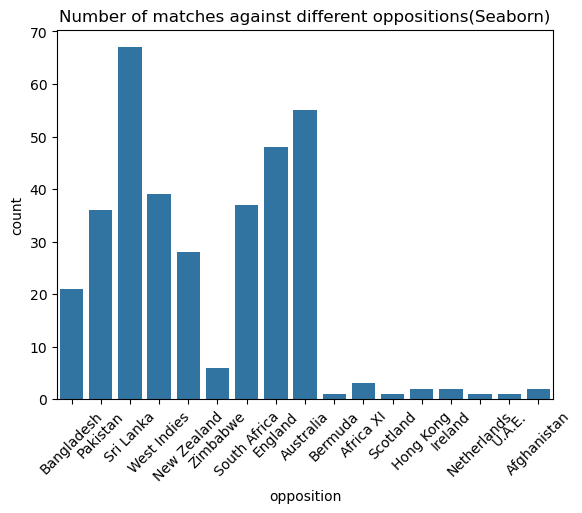

In [29]:
sns.countplot(x='opposition', data =df)
plt.title('Number of matches against different oppositions(Seaborn)')
plt.xticks(rotation=45)
plt.show()

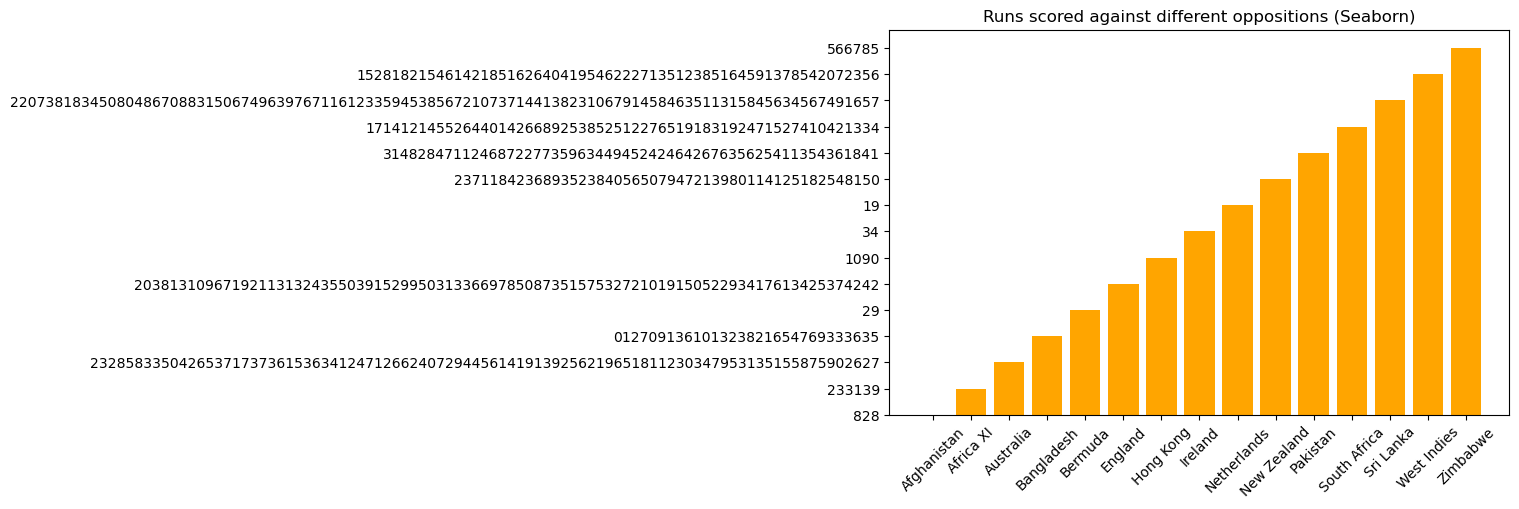

In [33]:
#runs scored against each team
runs_scored_by_opposition= df_new.groupby('opposition')['runs_scored'].sum().reset_index()

#matplotlib
plt.figure(figsize=(8,5))
plt.bar(runs_scored_by_opposition['opposition'],runs_scored_by_opposition['runs_scored'],color='orange')
plt.title("Runs scored against different oppositions (Seaborn)")
plt.xticks(rotation=45)
plt.show()